<style>
  p, li, ul, span {
    font-size: 16px !important;
    line-height: 1.6 !important;
  }
</style>

# Bellabeat Fitbit Case Study

## 📝 Project Overview
A comprehensive data analysis project examining consumer smart device usage to guide future marketing strategies for Bellabeat. Using R and SQL for data manipulation and visualization, this case study uncovers fitness and lifestyle trends from Fitbit data and applies them to the Bellabeat App to provide actionable, data-driven business recommendations. 

## 🎯 Business Task
**The primary objective:** Analyze non-Bellabeat smart device fitness data to identify trends in how consumers use these devices. Apply these insights to one specific Bellabeat product to provide high-level recommendations that will inform and guide Bellabeat's future marketing strategy.

**Product focus:** I will be focusing on the Bellabeat app as it is the central hub connecting all the smart devices. This will provide the most flexibility to draw connections between activity, sleep, and stress data.

## 🛠️ Technical Toolkit
* **R:** Primary tool for data cleaning.
* **SQL:** Data processing, analysis, and manipulation.
* **ggplot2:** Data visualization.
* **Kaggle Notebook:** End-to-end documentation of the data analysis process.
* **Power Bi:** Advanced and interactive visualizations.

## 🏷️ Citations/Acknowledgments 
1. During the 'Prepare' and 'Process' phases of this case study, my approach to data selection and my understanding of the dataset's limitations were heavily inspired by [Anson Tse](https://www.kaggle.com/ansontse)'s excellent analysis, '[Bellabeat Analysis with SQL](https://www.kaggle.com/code/ansontse/bellabeat-analysis-with-sql)', available on [Kaggle](https://www.kaggle.com/).
2. To better understand unfamiliar terms, for example "MET" or "intensities", I referenced [The Ultimate Guide to Fitbit Zone Minutes](https://fitstraps.co.uk/blogs/news/the-ultimate-guide-to-fitbit-zone-minutes)
3. To get a definition of some ambiguously labeled data and to discover which unit of measurement was being used for distance, I referenced [Fitbit Data Dictionary](/kaggle/input/datasets/austinbynumahs10/fitbit-data-dictionary).

<hr>

## Phase 1: Ask
### **Business Task:**
Analyze non-Bellabeat smart device fitness data to identify trends in how consumers use these devices. Apply these insights to one specific Bellabeat product to provide high-level recommendations that will inform and guide Bellabeat's future marketing strategy.

### **Key Stakeholders:**
* **Urška Sršen:** Bellabeat’s cofounder and Chief Creative Officer
* **Sando Mur:** Mathematician and Bellabeat’s cofounder; key member of the
Bellabeat executive team
* **Bellabeat marketing analytics team:** A team of data analysts, which I belong to, responsible for collecting, analyzing, and reporting data that helps guide Bellabeat’s marketing strategy.

### **Guiding Questions:**
1. What are some trends in smart device usage?
2. How could these trends apply to Bellabeat customers?
3. How could these trends help influence Bellabeat marketing strategy?

<hr>

## Phase 2: Prepare
### **Data Sources:**
* **Dataset:** 1 month of data from Fitbit users.
* **Organization:** The data is provided in CSV format, containing details such as heartrate, calories, steps, and other metrics of physical activity.
* **Bias & Credibility:**
    * Reliable: Data is from 30 FitBit users who consented to the study, however the dataset lacks demographic information so there is no way to ensure this data aligns with Bellabeat's target audience of women.
    * Original: Data is from primary tracking via Amazon Mechanical Turk.
    * Comprehensive: Data includes minute-level output for physical activity, however it is not consistent as some datasets are incomplete. Also the sample size, 30 users, is small when you consider the these inconsistencies. Finally the dataset lacks documentation, so I have included cited sources below to help define terms and clarify unfamiliar concepts.
    * Current: Data is not current (from 2016), meaning habits may have changed.
    * Cited: Source is documented.
* **Licensing & Privacy:** Data is public, anonymized and no personally identifiable information is accessible.

### **Data Selection & Exclusion**
Upon initial inspection of the 11 dataset files that were shortlisted by [Anson Tse](https://www.kaggle.com/ansontse) in their [Bellabeat Analysis with SQL](https://www.kaggle.com/code/ansontse/bellabeat-analysis-with-sql), it was determined that the dailyCalories_merged.csv, dailyIntensities_merged.csv, and dailySteps_merged.csv files are completely redundant, as all of their respective metrics are fully consolidated within the dailyActivity_merged.csv file. To maintain a clean and memory-efficient environment, these redundant files were deliberately excluded from the import process. The heartrate_seconds table was excluded due to insufficient sample size. Initially I had also excluded weightLogInfo because it only had 8 unique users. However as noted in the Phase 4 notes, I decided to use this information to help determine why this feature had such low adoption.

### **Exploring the Data:**
Before cleaning, I will use glimpse(), head(), and check for duplicates to understand the structure of my datasets.

In [1]:
# load essential libraries
library(tidyverse) # includes dplyr, ggplot2, tidyr, and readr
library(sqldf)     # allows running SQL queries on R data frames
library(lubridate) # essential for handling dates and times in the dataset
library(janitor) # standardizing column names during cleaning

# import 6 files from the 4.12.26 - 5.12.26 subset of data after following the data selection methodology from Anson Tse's case study (citation and link above)
daily_activity <- read_csv("/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/dailyActivity_merged.csv")
hourly_calories <- read_csv("/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/hourlyCalories_merged.csv")
hourly_intensities <- read_csv("/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/hourlyIntensities_merged.csv")
hourly_steps <- read_csv("/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/hourlySteps_merged.csv")
# during the prepare and process phases, i realized this dataset contains a column that once cleaned would be the same name as the dataset itself. to avoid confusion, it was easier just to name this daily_sleep instead of daily_day here
daily_sleep <- read_csv("/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/sleepDay_merged.csv")
weight_log_info <- read_csv("/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/weightLogInfo_merged.csv")

all_datasets <- list(
    "daily_activity" = daily_activity,
    "hourly_calories" = hourly_calories,
    "hourly_intensities" = hourly_intensities,
    "hourly_steps" = hourly_steps,
    "daily_sleep" = daily_sleep,
    "weight_log_info" = weight_log_info
)

# using purrr::iwalk to iterate through the list and its names
iwalk(all_datasets, ~{
    cat("\n\n--- Dataset:", .y, "---\n")
    glimpse(.x)
})

# force global CSS styling for larger markdown text
IRdisplay::display_html("<style> p, li, ul, span { font-size: 16px !important; line-height: 1.6 !important; } </style>")

# set global plot dimensions for ggplot2 (Width: 10, Height: 6)
options(repr.plot.width = 10, repr.plot.height = 6)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test


Rows: 940 Columns: 15
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): ActivityDate
dbl (14): Id, TotalSteps, TotalDistance, TrackerDista



--- Dataset: daily_activity ---
Rows: 940
Columns: 15
$ Id                       <dbl> 1503960366, 1503960366, 1503960366, 150396036…
$ ActivityDate             <chr> "4/12/2016", "4/13/2016", "4/14/2016", "4/15/…
$ TotalSteps               <dbl> 13162, 10735, 10460, 9762, 12669, 9705, 13019…
$ TotalDistance            <dbl> 8.50, 6.97, 6.74, 6.28, 8.16, 6.48, 8.59, 9.8…
$ TrackerDistance          <dbl> 8.50, 6.97, 6.74, 6.28, 8.16, 6.48, 8.59, 9.8…
$ LoggedActivitiesDistance <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ VeryActiveDistance       <dbl> 1.88, 1.57, 2.44, 2.14, 2.71, 3.19, 3.25, 3.5…
$ ModeratelyActiveDistance <dbl> 0.55, 0.69, 0.40, 1.26, 0.41, 0.78, 0.64, 1.3…
$ LightActiveDistance      <dbl> 6.06, 4.71, 3.91, 2.83, 5.04, 2.51, 4.71, 5.0…
$ SedentaryActiveDistance  <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ VeryActiveMinutes        <dbl> 25, 21, 30, 29, 36, 38, 42, 50, 28, 19, 66, 4…
$ FairlyActiveMinutes      <dbl> 13, 19, 11, 34, 10, 20, 16, 31,

### **Observations from glimpse run on all datasets:**
1. All column names are using CamelCase
2. Each dataframe contains a column to be converted from the character data type to a date or datetime object
3. All columns that reference distance are measured in kilometers [Fitbit Data Dictionary](/kaggle/input/datasets/austinbynumahs10/fitbit-data-dictionary)

In [2]:
# iterate through the list of datasets to explore the stats, number of missing values, column names of missing values, and number of duplicate rows
iwalk(all_datasets, ~{
    cat("\n==========\nDATASET:", toupper(.y), "\n==========\n")

    # calculate and print total missing values
    total_nas <- sum(is.na(.x))
    cat("Total Missing Values (NAs): ", total_nas, "\n")

    # identify and print specific columns with NA values
    if (total_nas > 0) {
        # find the names of columns where the sum of NAs is > 0
        na_cols <- names(.x)[colSums(is.na(.x)) > 0]
        cat("Columns with NAs: ", paste(na_cols, collapse = ", "), "\n")
        } else {
            cat("Columns with NAs: None\n")
        }

    # calculate and print number of duplicate rows
    total_dupes <- sum(duplicated(.x))
    cat("Total Duplicate Rows: ", total_dupes, "\n\n")

    # number of unique ids
    unique_id_count <- length(unique(.x$Id))
    cat("Total Unique Users: ", unique_id_count, "\n\n")

    # print the summary stats
    cat("--- Summary Stats ---\n")
    print(summary(.x))
    cat("\n")
    
})


DATASET: DAILY_ACTIVITY 
Total Missing Values (NAs):  0 
Columns with NAs: None
Total Duplicate Rows:  0 

Total Unique Users:  33 

--- Summary Stats ---
       Id            ActivityDate         TotalSteps    TotalDistance   
 Min.   :1.504e+09   Length:940         Min.   :    0   Min.   : 0.000  
 1st Qu.:2.320e+09   Class :character   1st Qu.: 3790   1st Qu.: 2.620  
 Median :4.445e+09   Mode  :character   Median : 7406   Median : 5.245  
 Mean   :4.855e+09                      Mean   : 7638   Mean   : 5.490  
 3rd Qu.:6.962e+09                      3rd Qu.:10727   3rd Qu.: 7.713  
 Max.   :8.878e+09                      Max.   :36019   Max.   :28.030  
 TrackerDistance  LoggedActivitiesDistance VeryActiveDistance
 Min.   : 0.000   Min.   :0.0000           Min.   : 0.000    
 1st Qu.: 2.620   1st Qu.:0.0000           1st Qu.: 0.000    
 Median : 5.245   Median :0.0000           Median : 0.210    
 Mean   : 5.475   Mean   :0.1082           Mean   : 1.503    
 3rd Qu.: 7.710   3rd Q

### **Observations:**
1. **"Zero Activity" Outliers:**
    * The minimum value for both `daily_activity.TotalSteps` and `daily_activity.TotalDistance` is 0. While it is possible for a user to be very inactive, having exactly zero steps usually suggests that the tracker was not worn that day or the battery had died.
    * The minimum value for `daily_activity.Calories` is 0. This is a significant data outlier because a living human burns calories even at rest (Basal Metabolic Rate). A zero-calorie reading confirms that the device was likely not being worn or failed to record data.
2. **"Full Day Sedentary" Outlier:** The maximum value for `daily_activity.SedentaryMinutes` is 1,440. Since there are exactly 1,440 minutes in a 24-hour day (60 minutes x 24 hours), this indicates that for at least one record, a user was recorded as sedentary for the entire day. This often occurs if a device is left stationary on a surface rather than being worn. I will be filtering to only include data that is < 1380 minutes, which allows for 23 hours of sedentary time. I noticed in other studies this limit was calculated by assuming a user slept for the typical 7 - 9 hours, making the limit between 960 and 1,050. I used a more generous buffer on this data point because I am also filtering out `daily_activity.TotalSteps` = 0.
3. **High-Activity Outliers:**
    * The maximum value for `daily_activity.TotalSteps` is 36,019, which is more than four times the mean of 7,638. While this is a physically possible number (equivalent to a marathon or a very long hike), it is a statistical outlier that will pull the overall average upward.
    * The maximum for `daily_activity.VeryActiveMinutes` is 210 (3.5 hours), whereas the median is only 4. This highlights a significant disparity between the average user and "power users" in the dataset.
4. **Duplicates:** `daily_sleep` has 3
5. **Logic Check:** The value for `daily_sleep.TotalTimeInBed` is always slightly higher than `daily_sleep.TotalMinutesAsleep`. This makes logical sense (it takes time to fall asleep), which confirms the data's integrity.
7. **Cleanliness:** The `hourly_steps`, `hourly_calories`, and `hourly_intensities` datasets are remarkably clean. There are zero missing values (NAs) and zero duplicate rows across all three.
8. **Activity Baselines:** The minimum value for `hourly_steps.StepTotal` and `hourly_steps.TotalIntensity` is 0. This is perfectly normal for hourly data, as users are asleep for roughly 8 hours of the day.
9. **Unique Users:** The dataset documentation states 30 users participated, but there are 33 unique IDs.

### **Additional Data Limitations:**
1. The **high-activity outliers** noted above will skew the averages significantly since the sample size is so small. These are valid data points, so I chose to leave them in the analysis.

<hr>

## Phase 3: Process
### **Tools Used**
I am using R within a Kaggle Notebook for this project to clean the data efficiently and ensure the analysis is reproducible.

### Data Cleaning Steps
1. **Standardize Columns:**
    * Clean all column names to snake_case
1. **Transformation:**
    * **chr to date:**
        * `daily_activity$activity_date`
    * **chr to datetime:**
        * `hourly_calories$activity_hour`
        * `hourly_intensities$activity_hour`
        * `hourly_steps$activity_hour`
        * `daily_sleep$sleep_day`
1. **Remove Duplicates:**
    * `daily_sleep`
1. **Filtering:** Only include rows where...
    * `daily_activity$total_steps` > 0
    * `daily_activity$total_distance` > 0
    * `daily_activity$sedentary_minutes` < 1380

In [3]:
# standardize columns - clean all data frames in the list and save them back to the list
all_datasets <- map(all_datasets, clean_names)

# overwrite the original variables in the global environment with the cleaned versions
list2env(all_datasets, envir = .GlobalEnv)

# transformation - convert chr to date or datetime
all_datasets <- imap(all_datasets, ~ {
  if (.y == "daily_activity") {
    # this one is only a date, no time
    .x %>% mutate(activity_date = as.Date(parse_date_time(activity_date, orders = "mdy")))
  } else {
    # all others are datetime
    .x %>% mutate(across(where(is.character), mdy_hms))
  }
})

# update the global environment again with the new data type conversions
list2env(all_datasets, envir = .GlobalEnv)

# remove duplicates
daily_sleep <- daily_sleep %>% distinct()

# keep a copy of unfiltered data specifically for tracking device usage and wear habits
daily_usage_tracking <- daily_activity

# filtering out unwanted data for actual physical activity trends
daily_activity <- daily_activity %>%
    filter(total_steps > 0, total_distance > 0, sedentary_minutes < 1380)

# update all_datasets list with the new distinct and filtered data
all_datasets <- mget(names(all_datasets))

# iwalk(all_datasets, ~{
#    cat("\n", .y, "\n")
#    glimpse(.x)
#})

<environment: R_GlobalEnv>

<environment: R_GlobalEnv>

<hr>

## Phase 4: Analyze

### **Analysis Summary:**
* About 36% of the users logged less than 25 days out of the month.
* Our data shows that sleeping for 9 hours does not automatically make a user more active the next day than sleeping for 6 hours. Therefore, marketing shouldn't promise that 'Better sleep leads to higher step counts.' Instead, we should look at sleep quality.
* Whether a user wears their device 5 days a month or 30 days a month, their actual sleep quality is exactly the same. Bellabeat shouldn't market their devices by saying "wear it more to sleep better" because the data doesn't support that.
    

In [4]:
# create a behavorial segmentation table
user_usage_summary <- daily_usage_tracking %>%
    group_by(id) %>%
    summarize(
        tracked_days = n_distinct(activity_date),
        # using the same criteria as earlier to get actually active data
        active_days = sum(total_steps > 0 & total_distance > 0 & sedentary_minutes < 1380, na.rm = TRUE),
        discarded_days = tracked_days - active_days
    ) %>%
mutate(
    usage_cat = case_when(
        active_days >= 25 ~ "High Use",
        active_days >= 15 ~ "Medium Use",
        TRUE ~ "Low Use"
    )
) %>%
arrange(desc(tracked_days))

# extract features from the weight log
weight_features <- weight_log_info %>%
    group_by(id) %>%
    summarize(
        # if they are in this table at all, they have a weight log
        has_weight_log = TRUE
    )

# left join the new features into the user summary
# using R instead of SQL for this join due to sqldf's lack of native TRUE/FALSE boolean type
user_usage_summary <- user_usage_summary %>%
    left_join(weight_features, by = "id") %>%
    mutate(
        # users who were not in the weight log will have NA
        # change the NA to FALSE
        has_weight_log = replace_na(has_weight_log, FALSE)
    )

# query to join daily activity and the new user categories
query <- "
SELECT
    a.*,
    u.usage_cat,
    u.has_weight_log
FROM daily_activity AS a
INNER JOIN user_usage_summary AS u
    ON a.id = u.id;
"

# execute the query to create combined dataset
segmented_activity <- sqldf(query)

#fix the date/datetime mismatch by forcing sleep_day to standard date
daily_sleep <- daily_sleep %>%
    mutate(sleep_day = as.Date(sleep_day))

# query to join sleep data into our segmentation table
query <- "
SELECT
    a.*,
    s.total_minutes_asleep,
    s.total_time_in_bed
FROM segmented_activity AS a
LEFT JOIN daily_sleep AS s
    ON a.id = s.id AND a.activity_date = s.sleep_day
"

# execute the query to update the segmentation table
segmented_activity <- sqldf(query)

# query to get sum of discarded days per usage category
query <- "
SELECT 
    usage_cat,
    SUM(discarded_days) AS total_discarded
FROM user_usage_summary
GROUP BY usage_cat
ORDER BY total_discarded DESC
"

# execute the query
discarded_data <- sqldf(query)

# calculate the counts and percentages for a plot
usage_pie_data <- user_usage_summary %>%
    count(usage_cat) %>%
    mutate(percentage = n / sum(n),
         label = scales::percent(percentage, accuracy = 1)) # format as XX%

# calculate sleep quality (restless/awake percentage) using the pre-aggregated daily metrics
segmented_activity <- segmented_activity %>%
    mutate(restless_percent = (total_time_in_bed - total_minutes_asleep) / total_time_in_bed)

# calculate the average restless percentage per category
sleep_quality_summary <- segmented_activity %>%
    filter(!is.na(restless_percent)) %>%
    group_by(usage_cat) %>%
    summarize(avg_restless_pct = mean(restless_percent))

<hr>

## Phase 5: Share

### **1. User Consistency and Retention**

**Business Question:** How consistently do users actually wear their smart devices over a 31-day period?
To understand user retention, I categorized our 33 users into three groups based on how many days they actively tracked physical activity: High Use (25+ days), Medium Use (15-24 days), and Low Use (less than 15 days).

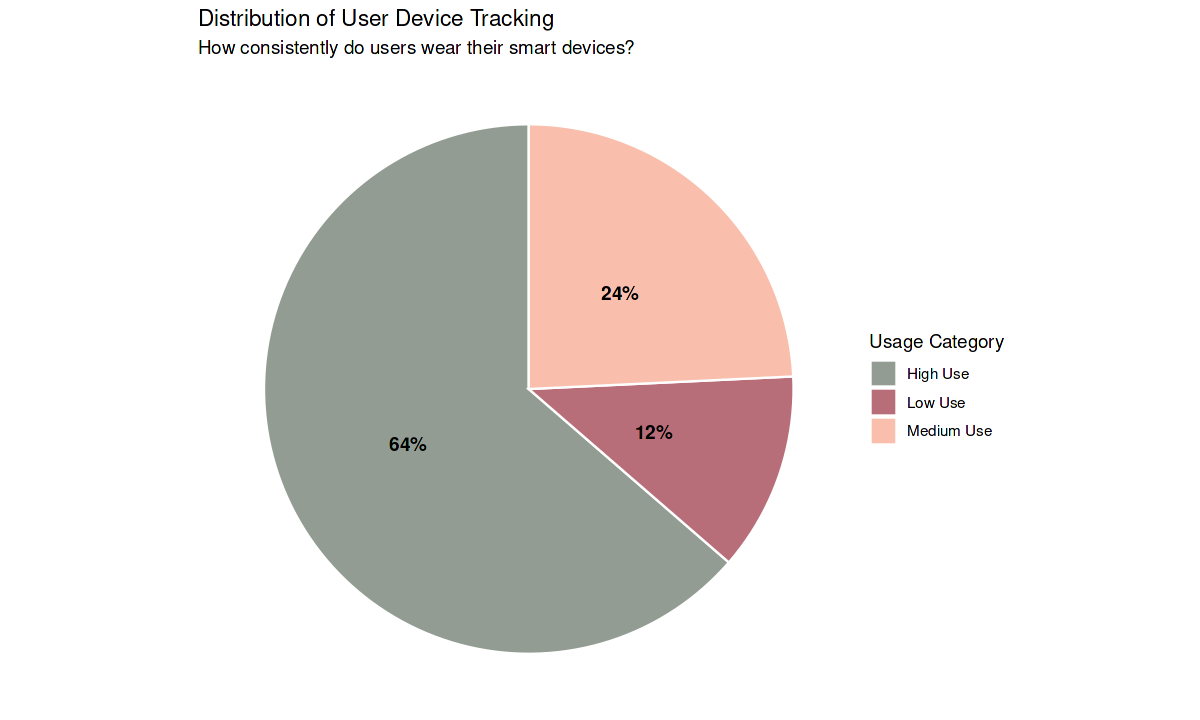

In [5]:
# create a pie chart
ggplot(data = usage_pie_data, aes(x = "", y = n, fill = usage_cat)) +
    # first create a single stacked bar
    geom_bar(stat = "identity", width = 1, color = "white") +
    # bend the y axis into a circle
    coord_polar("y", start = 0) +
    # add the labels in the middle of each slice
    geom_text(aes(label = label), position = position_stack(vjust = 0.5), color = "black", fontface = "bold") +
    # clean up theme (remove background, gridlines, and axes)
    theme_void() +
    # add a title and customize the legend
    labs(title = "Distribution of User Device Tracking",
         subtitle = "How consistently do users wear their smart devices?",
         fill = "Usage Category") +
    # customize colors to match Bellabeat's aesthetic (scraped bellabeat.com for most used colors besides white or black)
    scale_fill_manual(values = c("High Use" = "#929C92", "Medium Use" = "#F9BEAC", "Low Use" = "#B76E79"))

**Observation & Insight:** While a strong majority of users fall into the "High Use" category, a significant portion still struggle with daily consistency, falling into the Medium and Low use buckets. This indicates that while initial adoption is strong, long-term daily retention drops off for a segment of the user base. Bellabeat must focus on post-purchase engagement to keep users in the "High Use" category.



### **2. Identifying "Device Fatigue"**

**Business Question:** Are users actively choosing to take off their devices, and which user segment does this the most?
Initially, I noticed several days in the dataset where users recorded exactly 0 steps and 1440 sedentary minutes. Rather than deleting these as errors, I analyzed them as "Discarded Days"—days where the user actively chose to take the device off and leave it behind.

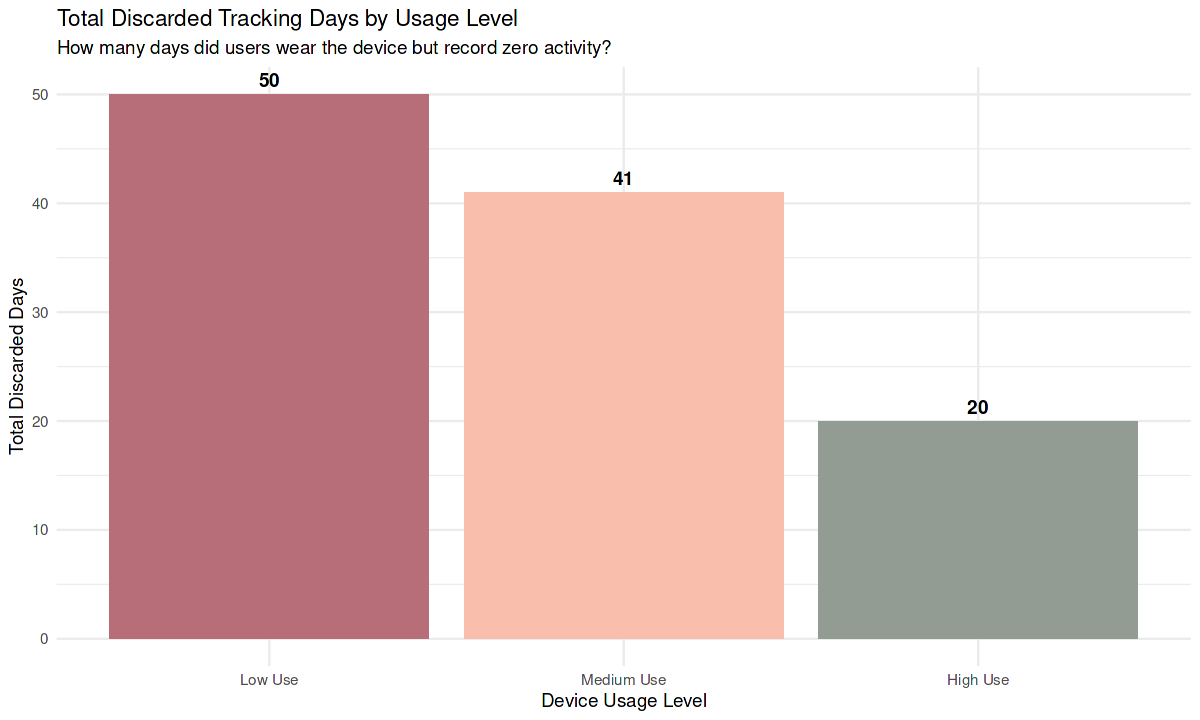

In [6]:
# total discarded days by usage category
ggplot(data = discarded_data, aes(x = reorder(usage_cat, -total_discarded), y = total_discarded, fill = usage_cat)) +
    geom_col() +
    # display the exact number on top of each bar for easy reading
    geom_text(aes(label = total_discarded), vjust = -0.5, fontface = "bold") +
    theme_minimal() +
    labs(
        title = "Total Discarded Tracking Days by Usage Level",
        subtitle = "How many days did users wear the device but record zero activity?",
        x = "Device Usage Level",
        y = "Total Discarded Days"
    ) +
    # remove the legend because the x-axis already labels the categories
    theme(legend.position = "none") +
    # customize colors to match Bellabeat's aesthetic (scraped bellabeat.com for most used colors besides white or black)
    scale_fill_manual(values = c("High Use" = "#929C92", "Medium Use" = "#F9BEAC", "Low Use" = "#B76E79"))

**Observation & Insight:** The data reveals a massive spike in discarded days among the "Low Use" and "Medium Use" categories. These users are experiencing severe "Device Fatigue." They aren't just forgetting to put the watch on; they are intentionally taking it off and leaving it on a nightstand, likely due to physical discomfort (bulky wristbands) or the frustration of constant battery charging.



### **3. Feature Engagement (Manual Weight Logging)**

**Business Question:** Are consistent device wearers more likely to engage with tedious manual tracking features, like the weight log?
Manual data entry is a known friction point in UX design. I wanted to see if a user's daily activity level correlated with their willingness to manually log their weight.

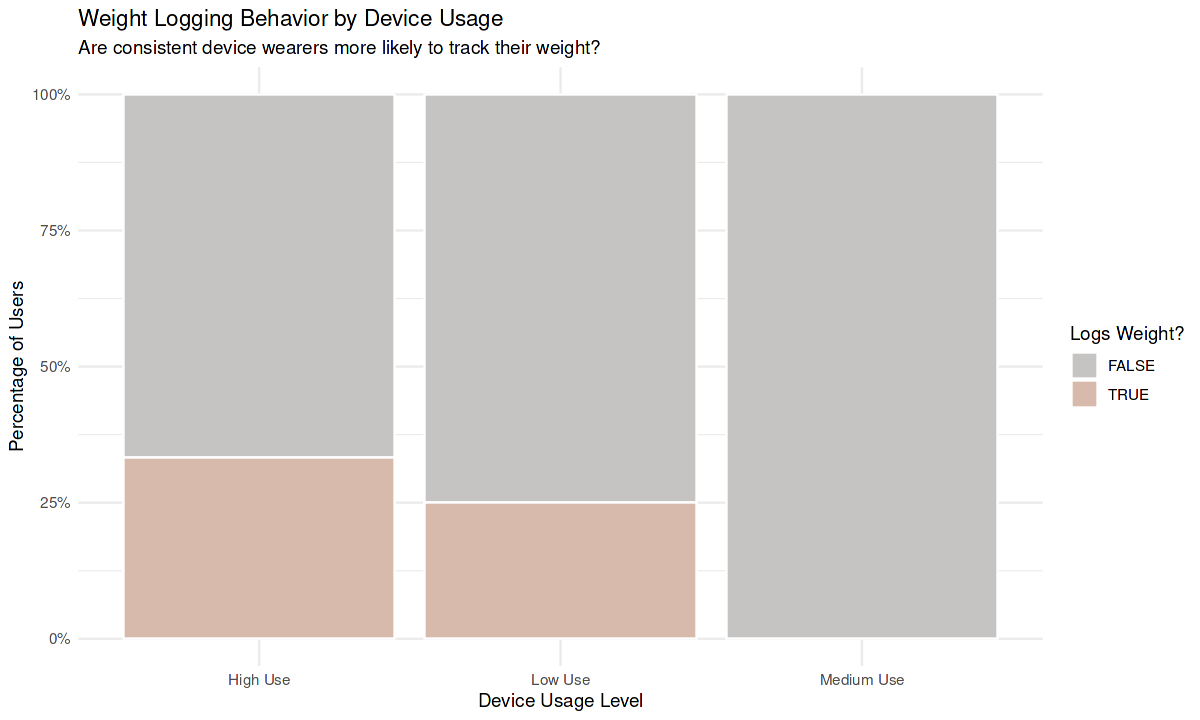

In [7]:
# proportion of weight logging by usage category
ggplot(data = user_usage_summary, aes(x = usage_cat, fill = has_weight_log)) +
    # position = "fill" makes all bars exactly 100% tall, so we can compare proportions
    geom_bar(position = "fill", color = "white") +
    # format the y-axis as percentages
    scale_y_continuous(labels = scales::percent) +
    # add labels and theme
    labs(
        title = "Weight Logging Behavior by Device Usage",
        subtitle = "Are consistent device wearers more likely to track their weight?",
        x = "Device Usage Level",
        y = "Percentage of Users",
        fill = "Logs Weight?"
    ) +
    # clean, modern theme
    theme_minimal() +
    # customize colors to match Bellabeat's aesthetic (scraped bellabeat.com for most used colors besides white or black)
    scale_fill_manual(values = c("TRUE" = "#D7BAAC", "FALSE" = "#C6C4C3"))

**Observation & Insight:** Only a small fraction of the total user base (8 out of 33) engages with the weight logging feature, proving that manual data entry is highly unpopular. However, the chart clearly shows that "High Use" daily wearers are significantly more likely to log their weight than casual users. Casual users entirely abandon manual tracking features.



### **4. The Relationship Between Sleep and Activity**

**Business Question:** Does getting a longer night of sleep naturally lead to a more physically active day?
Fitness brands often market the idea that more sleep results in higher daily step counts. I wanted to test if Bellabeat's user data actually supports this claim by plotting total minutes asleep against total daily steps.

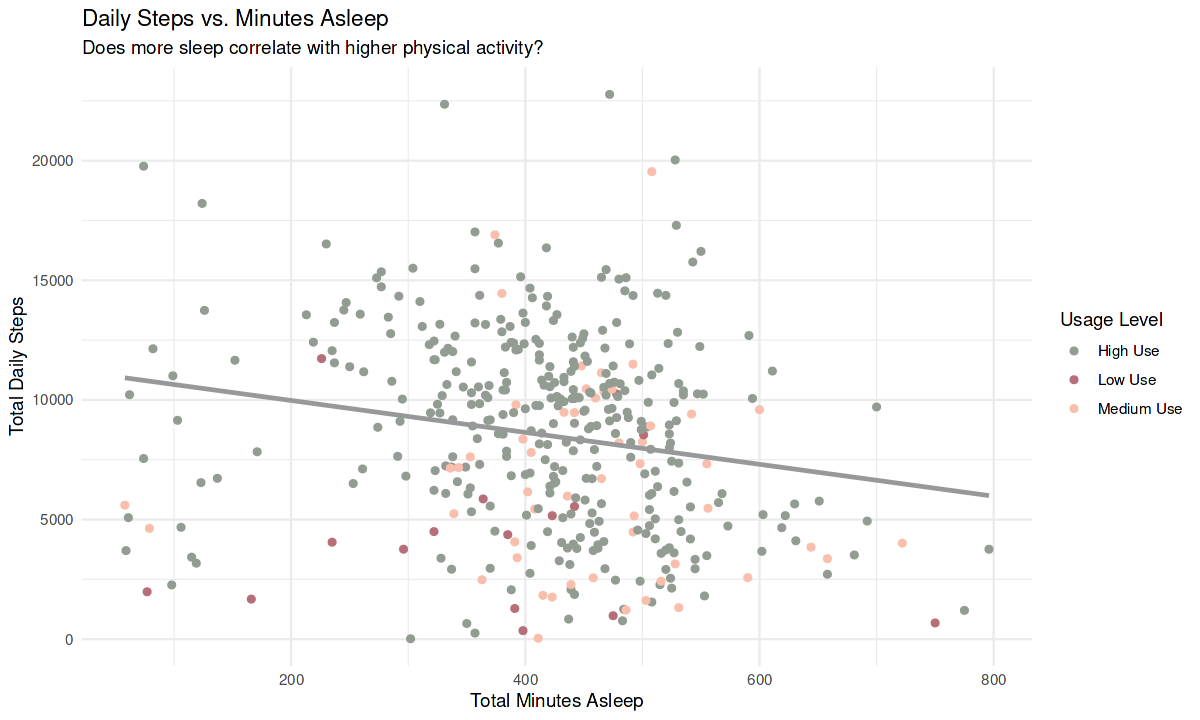

In [8]:
# correlation between sleep and daily steps
# filter out the NAs first so ggplot doesn't throw a warning message
ggplot(data = filter(segmented_activity, !is.na(total_minutes_asleep)), 
       aes(x = total_minutes_asleep, y = total_steps)) +
    geom_point(aes(color = usage_cat)) +
    # add a trend line to see the overall relationship
    geom_smooth(method = "lm", formula = y ~ x, color = "#97989A", se = FALSE) +
    theme_minimal() +
    labs(
        title = "Daily Steps vs. Minutes Asleep",
        subtitle = "Does more sleep correlate with higher physical activity?",
        x = "Total Minutes Asleep",
        y = "Total Daily Steps",
        color = "Usage Level"
    ) +
    # customize colors to match Bellabeat's aesthetic (scraped bellabeat.com for most used colors besides white or black)
    scale_color_manual(values = c("High Use" = "#929C92", "Medium Use" = "#F9BEAC", "Low Use" = "#B76E79"))

**Observation & Insight:** The scatterplot reveals a fascinating **Null Finding**: there is zero correlation between how long a user sleeps and how many steps they take the next day. The trendline is completely flat. Because of this, Bellabeat should not promise users that tracking their sleep will make them more active. Instead, I need to pivot my analysis to see if device usage impacts sleep quality, rather than sleep duration.



### **4. Sleep Quality vs. Device Usage**

**Business Question:** Does wearing the fitness tracker more frequently correlate with getting a better night's rest?
To answer this, I calculated the average percentage of the night that users spent "awake" or "restless" while in bed, and compared it across our three usage categories.

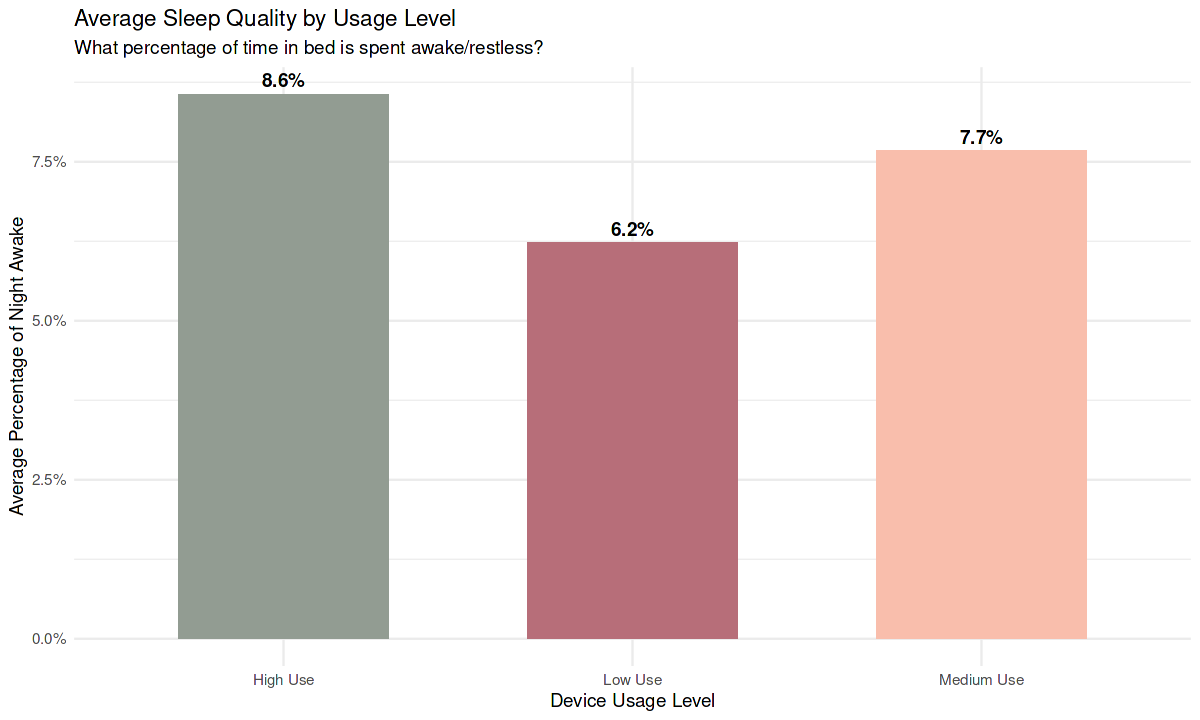

In [9]:
# sleep quality by usage category
ggplot(data = sleep_quality_summary, aes(x = usage_cat, y = avg_restless_pct, fill = usage_cat)) +
    geom_col(width = 0.6) +
    # format y-axis as percentage
    scale_y_continuous(labels = scales::percent) +
    # add text labels with one decimal place accuracy
    geom_text(aes(label = scales::percent(avg_restless_pct, accuracy = 0.1)), vjust = -0.5, fontface = "bold") +
    theme_minimal() +
    labs(
        title = "Average Sleep Quality by Usage Level",
        subtitle = "What percentage of time in bed is spent awake/restless?",
        x = "Device Usage Level",
        y = "Average Percentage of Night Awake"
    ) +
    theme(legend.position = "none") +
    # customize colors to match Bellabeat's aesthetic (scraped bellabeat.com for most used colors besides white or black)
    scale_fill_manual(values = c("High Use" = "#929C92", "Medium Use" = "#F9BEAC", "Low Use" = "#B76E79"))

**Observation & Insight:** This chart reveals a highly valuable **Null Finding**. Across all three usage levels, the average percentage of the night spent restless or awake is practically identical. Wearing a fitness tracker more often does not inherently improve sleep quality. Therefore, Bellabeat's marketing should not make claims that wearing the device will "cure" bad sleep, but rather position the device as a neutral tool to help women understand their baseline sleep habits.

<hr>

## Phase 6: Act

### **Combat "Device Fatigue" with the Bellabeat Leaf:**
* **The Data:** Low and Medium usage categories discard their devices (0 steps) twice as often as High Use users.
* **The Recommendation:** Users are taking off their trackers and leaving them behind, likely due to discomfort or needing to charge them. Bellabeat should aggressively market the **Bellabeat Leaf** to these specific user segments. By highlighting that the Leaf can be worn as a necklace or clip (eliminating "wrist fatigue") and has a 6-month battery life (no daily charging), Bellabeat can capture the market of women who abandon standard smartwatches.

### **Reframing the Sleep Narrative:**
* **The Data:** There is no correlation between getting more sleep and taking more steps the next day. Furthermore, usage frequency does not impact sleep quality—users experience roughly the same percentage of restlessness regardless of their habits.
* **The Recommendation:** Bellabeat's marketing team should avoid making claims like _"Wear our tracker more to sleep better"_ or _"Better sleep means a more active you,"_ because the data simply doesn't support it. Instead, marketing campaigns should focus on **"Understanding Your Baseline."** Position the sleep tracker as a tool for recovery and self-awareness, rather than a hack to boost daily productivity.

### **Targeted Cross-Selling for the Smart Scale:**
* **The Data:** Manual weight logging has extremely low overall adoption, but "High Use" daily wearers are the most likely to engage with it.
* **The Recommendation:** Stop wasting marketing spend trying to convince casual users to log their weight manually. Instead, use targeted in-app push notifications to advertise Bellabeat's connected smart scale directly, and exclusively, to the "High Use" segment. They are already deeply engaged with the ecosystem and are the most likely to purchase a frictionless, auto-syncing scale.

